# Improving Computer Vision Accuracy using Convolutions

지금까지 Deep Neural Network (DNN) 를 이용해서 패션 mnist 를 분류했다.  

In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten

2026-09-01 09:09:18.322588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 09:09:18.333886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-01 09:09:18.346780: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-01 09:09:18.350338: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-01 09:09:18.359745: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf
# TensorFlow가 GPU 메모리를 처음부터 크게 선점하지 않고, 필요한 만큼 점진적으로 사용하도록 설정
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1788221360.535403   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221360.580600   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221360.580650   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
mnist = tf.keras.datasets.fashion_mnist

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
X_test.shape

(10000, 28, 28)

In [8]:
# 이미지 처리에서는 이미지를 그대로 사용함.

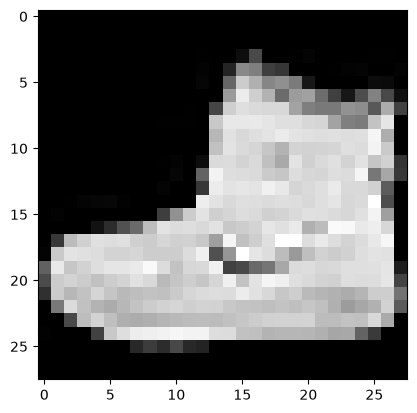

In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap='gray')
plt.show()

- image 데이터 표현

In [10]:
# gray scale
60000, 28, 28, 1

(60000, 28, 28, 1)

DNN에서는 정확도가, 트레이닝셋은 89% 정도이고 테스트셋으로는  87% 정도가 나왔다. 

이제 Convolutional Neural Networks 이용해서 정확도를 향상시켜본다.




In [11]:
from keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten
from tensorflow import keras

In [12]:
def build_model(input_shape):  # (28, 28, 1)
    model = Sequential()
    model.add(keras.Input(shape = input_shape))
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation=keras.activations.relu ))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    model.add(Conv2D(filters=32, kernel_size=(3,3), activation=keras.activations.relu))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    # 여기까지는 이미지의 특징 파악, 이후 분류를 위해 ANN 실행
    model.add(Flatten())
    model.add(Dense(128, keras.activations.relu))
    model.add(Dense(10, keras.activations.softmax))

    # model compile
    model.compile(optimizer=keras.optimizers.Adam(), 
                  loss= keras.losses.SparseCategoricalCrossentropy(),
                  metrics=[keras.metrics.SparseCategoricalAccuracy()])
    return model
    


In [13]:
model = build_model((28,28,1))

I0000 00:00:1788221361.106597   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221361.106666   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221361.106693   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221361.197685   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1788221361.197776   40042 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-01

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,922 (480.16 KB)

 Trainable params: 122,922 (480.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NVIDIA GeForce GTX 1050 2G VRAM에서 tensorflow 2.21 버전 사용시 발생한 오류
# NVIDIA 오래된 모델을 사용할 경우 Tensorflow 최신버전 사용한 제한될 수 있음.
# InternalError: Graph execution error:
# ...

#   File "/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py", line 125, in wrapper

# Autotuning failed for HLO: %cudnn-conv-bias-activation.6 = (f32[4,64,26,26]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.17, %transpose, %arg3.1), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/conv2d_2_1/convolution" source_file="/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1221}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} with error: NOT_FOUND: No valid config found!
# 	 [[{{node StatefulPartitionedCall}}]] [Op:__inference_multi_step_on_iterator_1703]

In [ ]:
#  NVIDIA GeForce GTX 1050 2G VRAM
# UDA/cuDNN 조합에서 GTX 1050의 Conv2D/cuDNN 실행 호환성 문제
# VRAM 부족보다는 TensorFlow 2.21.0 + 현재 CUDA/cuDNN 조합의 GPU convolution 호환 문제로 보는 것이 더 타당
# 즉, cuDNN이 Conv2D 연산에 사용할 수 있는 유효한 커널 구성을 찾지 못한 것이다. 
# 현재 TensorFlow 2.21.0 공식 빌드는 CUDA 12.5, cuDNN 9.3 기준인데, 
# 현재 uv 환경에는 CUDA 12.9 계열과 cuDNN 9.25가 설치되어 있다. 공식 빌드 조합과 차이가 있다.

# 확인방법
# uv pip show nvidia-cuda-runtime-cu12
# uv pip show nvidia-cudnn-cu12
# uv pip show tensorfow

# rm -rf .venv
# uv init --bare
# uv add "tensorflow[and-cuda]==2.20.0"  <-- 이것도 오류, NVIDIA GeForce GTX 1050
# uv add "tensorflow[and-cuda]==2.17.1"  <-- 여기서 학습이 됨, NVIDIA GeForce GTX 1050

# README.md 파일 참고해서 가상환경 셋팅하기

# uv run python -c "import tensorflow as tf; print(tf.__version__); print(tf.config.list_physical_devices('GPU'))"


In [ ]:
history = model.fit(
  X_train, y_train, 
  epochs=20, 
  batch_size=8,
  # validation_data=(X_test, y_test)
  validation_split=0.2
  )

Epoch 1/20


I0000 00:00:1788221362.576532   40189 service.cc:146] XLA service 0x7dfa64005540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788221362.576556   40189 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-09-01 09:09:22.590667: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-01 09:09:22.682964: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  64/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 1.6214 - sparse_categorical_accuracy: 0.4434   

I0000 00:00:1788221363.834354   40189 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6000/6000 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.4350 - sparse_categorical_accuracy: 0.8400 - val_loss: 0.3506 - val_sparse_categorical_accuracy: 0.8702
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.2977 - sparse_categorical_accuracy: 0.8897 - val_loss: 0.3305 - val_sparse_categorical_accuracy: 0.8781
Epoch 3/20
 247/6000 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.2465 - sparse_categorical_accuracy: 0.9104

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6703 - sparse_categorical_accuracy: 0.8990


[0.6703060269355774, 0.8989999890327454]

## 학습결과 확인

In [ ]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

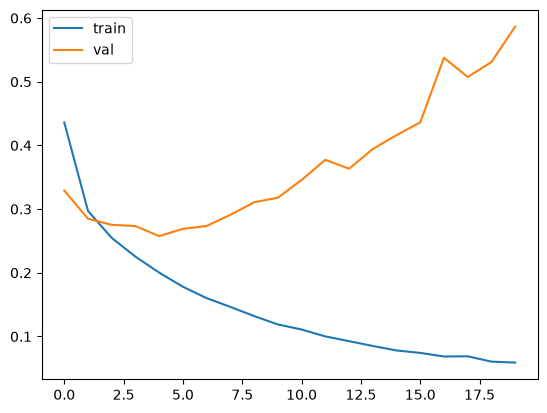

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()


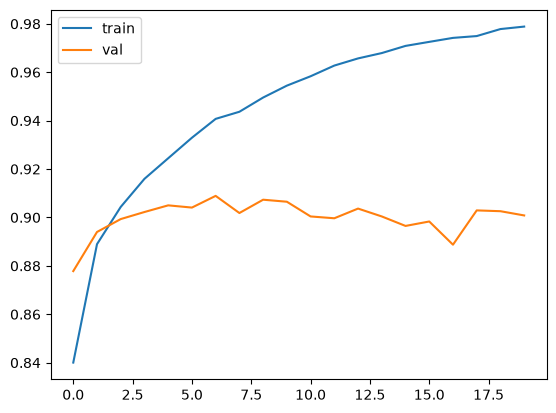

In [ ]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.legend(['train', 'val'])
plt.show()

## 모델 평가

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
y_pred_pro = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred_pro

array([[9.3064063e-27, 4.1910631e-27, 1.6184028e-26, ..., 5.5721454e-17,
        6.9337926e-34, 1.0000000e+00],
       [1.3037892e-21, 1.4504840e-41, 1.0000000e+00, ..., 4.7933401e-28,
        2.0011201e-29, 1.7558270e-42],
       [9.9761735e-26, 1.0000000e+00, 5.0815482e-34, ..., 4.7504018e-43,
        1.4012985e-45, 0.0000000e+00],
       ...,
       [4.0928285e-40, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00],
       [3.8431423e-23, 1.0000000e+00, 5.2506297e-30, ..., 9.1962222e-36,
        1.2051167e-43, 2.8025969e-45],
       [7.6709582e-22, 2.5517869e-31, 3.4229389e-22, ..., 6.1248500e-09,
        5.2734960e-14, 7.0445229e-17]], dtype=float32)

In [ ]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.899

In [ ]:
# Fashion MNIST 클래스 이름
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 예측 label 이름으로 변환
predicted_labels = [class_names[i] for i in y_pred_labels]

In [ ]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [ ]:
import pandas as pd
df = pd.DataFrame(data=cm, columns=class_names)
df.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,829,0,28,35,2,1,98,0,7,0
1,2,972,1,19,2,0,3,0,1,0
2,16,0,842,8,58,0,74,0,2,0
3,11,5,12,928,28,0,13,0,3,0
4,1,0,71,32,843,0,52,0,1,0


<Axes: >

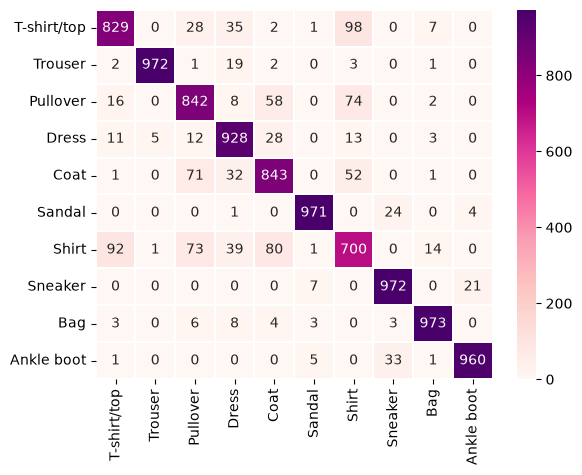

In [ ]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df.columns,
          yticklabels=df.columns)

## EarlyStopping으로 다시 학습

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 새로운 초기 가중치로 처음부터 다시 학습
# del model
tf.keras.backend.clear_session()

model = build_model((28,28,1))

In [ ]:
# callback, 함수
# EarlyStopping(monitor='val_loss', mode=validation 로스 최소, patience=loss 올라가는것을 몇번 참느냐?, 
#  restore_best_weights=True weight가 가장 좋았던 상태로 되돌리기 )
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

In [ ]:
# patience=5의 의미
# Epoch 10 : val_loss = 0.30  ← 최고 성능
# Epoch 11 : 개선 없음        ← 1
# Epoch 12 : 개선 없음        ← 2
# Epoch 13 : 개선 없음        ← 3
# Epoch 14 : 개선 없음        ← 4
# Epoch 15 : 개선 없음        ← 5 → 중단

In [ ]:
# 학습
history2 = model.fit(
  X_train, y_train, 
  epochs = 100, 
  validation_split=0.2, 
  callbacks=[early_stopping])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4938 - sparse_categorical_accuracy: 0.8189 - val_loss: 0.3926 - val_sparse_categorical_accuracy: 0.8517
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3331 - sparse_categorical_accuracy: 0.8781 - val_loss: 0.3439 - val_sparse_categorical_accuracy: 0.8708
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2851 - sparse_categorical_accuracy: 0.8941 - val_loss: 0.2834 - val_sparse_categorical_accuracy: 0.8942
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2527 - sparse_categorical_accuracy: 0.9069 - val_loss: 0.2950 - val_sparse_categorical_accuracy: 0.8967
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2269 - sparse_categorical_accuracy: 0.9145 - val_loss: 0.2818 - val_sparse_categorical_accuracy: 0.9004
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2064 - sparse_categorical_accuracy: 0.9219 - val_loss: 0.2537 - val_sparse_categorical_acc

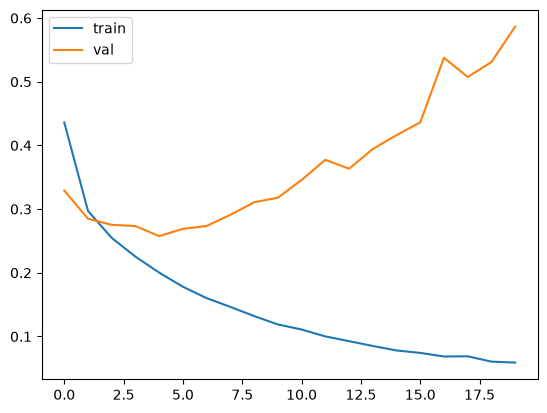

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.899

In [ ]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [ ]:
import pandas as pd
df2 = pd.DataFrame(data=cm, columns=class_names)
df2.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,829,0,28,35,2,1,98,0,7,0
1,2,972,1,19,2,0,3,0,1,0
2,16,0,842,8,58,0,74,0,2,0
3,11,5,12,928,28,0,13,0,3,0
4,1,0,71,32,843,0,52,0,1,0


<Axes: >

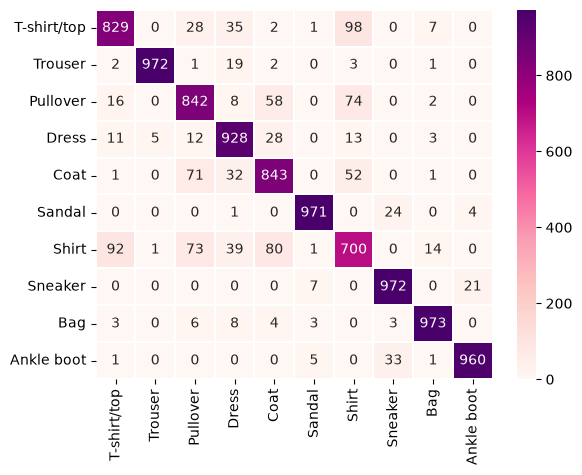

In [ ]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df2.columns,
          yticklabels=df2.columns)

트레이닝셋은 97% , 테스트셋은 89% 까지 나온다.


에포크를 20까지 해보면, 트레이닝셋 정확도는 올라가지만 밸리데이션 정확도는 내려간다. 즉, 오버핏팅이 된다.







```
import tensorflow as tf
mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
training_images=training_images.reshape(60000, 28, 28, 1)
training_images=training_images / 255.0
test_images = test_images.reshape(10000, 28, 28, 1)
test_images=test_images/255.0
```
